# Decision Trees

### Задача 1: Визуализация «мозга» дерева решений (Классика Kaggle — Титаник)

Деревья хороши тем, что их логику можно буквально нарисовать и прочитать глазами.

- **Датасет:** Известный датасет **"Titanic - Machine Learning from Disaster"** на Kaggle (`train.csv`). Задача — предсказать, выжил ли пассажир (`Survived`: 1 или 0).
- **Что нужно сделать:**
    1. Взять признаки: `Pclass` (класс билета), `Sex` (пол), `Age` (возраст, заполните пропуски медианой) и `Fare` (цена билета). Закодировать пол в 1 и 0.
    2. Обучить `DecisionTreeClassifier`, но строго ограничить его глубину: `max_depth=3`.
    3. Использовать функцию `plot_tree` из библиотеки `sklearn.tree`.
    4. Посмотреть на картинку. Какое правило оказалось на самом верху (в корне)? Прочитать путь для пассажира женского пола первого класса и определить, какой вердикт выносит модель.

In [690]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("titanic.csv")

df = df.dropna()
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [691]:
df_encoded = pd.get_dummies(df, columns=['Sex'], drop_first=True)
df_encoded = df_encoded[['Pclass', 'Sex_male', 'Age', 'Fare', 'Survived']]
print(df_encoded.head())

    Pclass  Sex_male   Age     Fare  Survived
1        1     False  38.0  71.2833         1
3        1     False  35.0  53.1000         1
6        1      True  54.0  51.8625         0
10       3     False   4.0  16.7000         1
11       1     False  58.0  26.5500         1


In [692]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['Survived'])
y = df_encoded['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [693]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42, max_depth=3)

dt_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

[Text(0.4444444444444444, 0.875, 'Sex_male <= 0.5\ngini = 0.441\nsamples = 146\nvalue = [48, 98]\nclass = Survived'),
 Text(0.2222222222222222, 0.625, 'Age <= 3.0\ngini = 0.134\nsamples = 69\nvalue = [5, 64]\nclass = Survived'),
 Text(0.3333333333333333, 0.75, 'True  '),
 Text(0.1111111111111111, 0.375, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]\nclass = Not Survived'),
 Text(0.3333333333333333, 0.375, 'Fare <= 10.481\ngini = 0.086\nsamples = 67\nvalue = [3, 64]\nclass = Survived'),
 Text(0.2222222222222222, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = Not Survived'),
 Text(0.4444444444444444, 0.125, 'gini = 0.059\nsamples = 66\nvalue = [2, 64]\nclass = Survived'),
 Text(0.6666666666666666, 0.625, 'Age <= 17.5\ngini = 0.493\nsamples = 77\nvalue = [43, 34]\nclass = Not Survived'),
 Text(0.5555555555555556, 0.75, '  False'),
 Text(0.5555555555555556, 0.375, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]\nclass = Survived'),
 Text(0.7777777777777778, 0.375, 'Age <= 53.0\ngini = 0.47\n

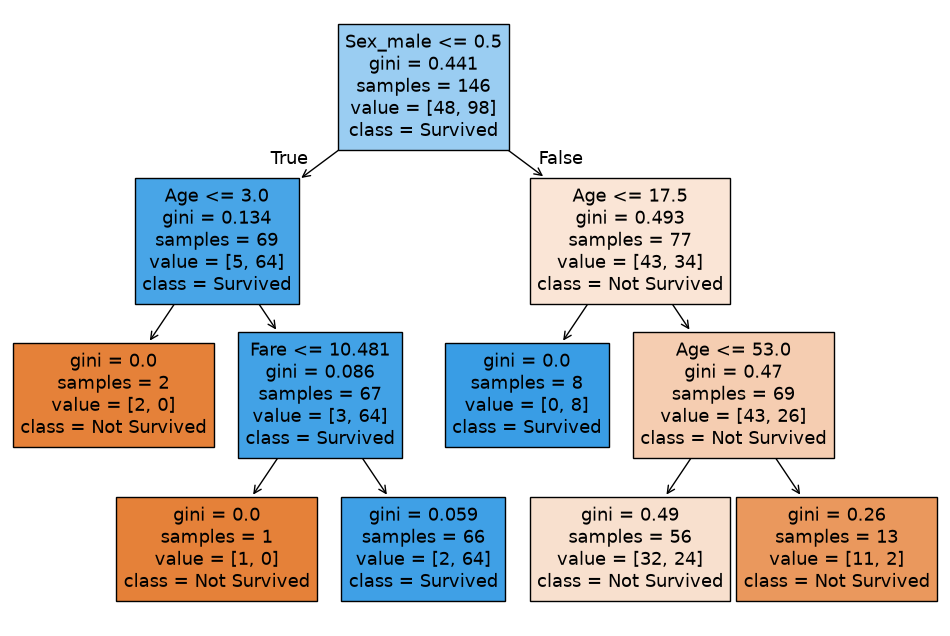

In [694]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12, 8))
plot_tree(dt_model, feature_names=X.columns, class_names=['Not Survived', 'Survived'], filled=True)

### Задача 2: Влияние глубины дерева на переобучение (Эксперимент)

- **Датасет:** Датасет вин из прошлых тем.
- **Что нужно сделать:**
    1. Разбить данные на Train и Test.
    2. Написать цикл, который меняет параметр `max_depth` от 1 до 20.
    3. Внутри цикла обучить дерево без других ограничений, записывая точность на Train и на Test.
    4. Построить график зависимостей. Найти точку, где точность на Train продолжает расти к 100%, а точность на Test начинает падать (это момент начала переобучения). Какая глубина оказалась оптимальной?

In [695]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_wine

df = load_wine(as_frame=True).frame

df = df.dropna()
df.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='str')

In [696]:
X = df.drop("target", axis=1)
y = df["target"]

In [697]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [698]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [699]:
from sklearn.tree import DecisionTreeClassifier

train_accuracy_list = []
test_accuracy_list = []
diff = []
neighbors_range = range(1, 21)

best_k = None
best_score = -float('inf')

for i in neighbors_range:
    knc_model = DecisionTreeClassifier(random_state=42, max_depth=i)
    knc_model.fit(X_train_scaled, y_train)
    
    train_accuracy = knc_model.score(X_train_scaled, y_train)
    test_accuracy = knc_model.score(X_test_scaled, y_test)
    
    train_accuracy_list.append(train_accuracy)
    test_accuracy_list.append(test_accuracy)

    gap = abs(train_accuracy - test_accuracy)
    
    balance_score = test_accuracy - gap
    
    print(f"n_neighbors: {i} | Test Acc: {test_accuracy:.4f} | Train Acc: {train_accuracy:.4f} | Gap: {gap:.4f} | Balance Score: {balance_score:.4f}")

    if balance_score > best_score:
        best_score = balance_score
        best_k = i

print(f"Идеальный выбор: max_depth = {best_k}")
print(f"Метрика баланса: {best_score:.4f}")

n_neighbors: 1 | Test Acc: 0.6667 | Train Acc: 0.6408 | Gap: 0.0258 | Balance Score: 0.6408
n_neighbors: 2 | Test Acc: 0.8611 | Train Acc: 0.9366 | Gap: 0.0755 | Balance Score: 0.7856
n_neighbors: 3 | Test Acc: 0.9444 | Train Acc: 0.9930 | Gap: 0.0485 | Balance Score: 0.8959
n_neighbors: 4 | Test Acc: 0.9444 | Train Acc: 1.0000 | Gap: 0.0556 | Balance Score: 0.8889
n_neighbors: 5 | Test Acc: 0.9444 | Train Acc: 1.0000 | Gap: 0.0556 | Balance Score: 0.8889
n_neighbors: 6 | Test Acc: 0.9444 | Train Acc: 1.0000 | Gap: 0.0556 | Balance Score: 0.8889
n_neighbors: 7 | Test Acc: 0.9444 | Train Acc: 1.0000 | Gap: 0.0556 | Balance Score: 0.8889
n_neighbors: 8 | Test Acc: 0.9444 | Train Acc: 1.0000 | Gap: 0.0556 | Balance Score: 0.8889
n_neighbors: 9 | Test Acc: 0.9444 | Train Acc: 1.0000 | Gap: 0.0556 | Balance Score: 0.8889
n_neighbors: 10 | Test Acc: 0.9444 | Train Acc: 1.0000 | Gap: 0.0556 | Balance Score: 0.8889
n_neighbors: 11 | Test Acc: 0.9444 | Train Acc: 1.0000 | Gap: 0.0556 | Balance 

В момент max_depth=3 test accuracy останавливает свой рост на 0.9444, после этого начинается переобучение

Text(0.5, 1.0, 'Decision Tree Accuracy for Different Max Depths')

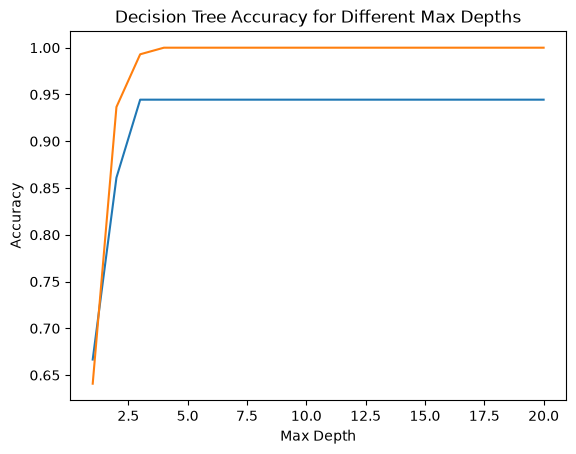

In [700]:
plt.plot(neighbors_range, test_accuracy_list)
plt.plot(neighbors_range, train_accuracy_list)
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy for Different Max Depths')

### Задача 3: Дерево решений в задаче регрессии (Нелинейные зависимости)

Дерево решений умеет предсказывать числа. Вместо голосования классов, в листах регрессионного дерева считается _среднее арифметическое_ всех объектов, попавших в этот лист.

- **Условие:** Сгенерировать сложную нелинейную функцию синуса с шумом:
    ```
    import numpy as np
    X = np.sort(5 * np.random.rand(80, 1), axis=0)
    y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])
    ```
- **Что нужно сделать:**
    1. Обучить обычную `LinearRegression` и `DecisionTreeRegressor(max_depth=4)` на этих данных.
    2. Сделать предсказания для густой сетки точек (например, `X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]`).
    3. Построить на одном графике: исходные точки (scatter), линию предсказания линейной регрессии и линию предсказания дерева решений.
    4. Описать разницу. Почему линейная регрессия провалилась, а дерево смогло повторить изгибы синусоиды? Обратить внимание на то, что график предсказаний дерева выглядит как «ступеньки», объяснить почему.

In [701]:
import numpy as np

np.random.seed(42) # фиксируем сид для воспроизводимости
X_train = np.sort(5 * np.random.rand(80, 1), axis=0)
y_train = np.sin(X_train).ravel() + np.random.normal(0, 0.1, X_train.shape[0])

X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_test = np.sin(X_test).ravel()

In [702]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.38]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.052
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[13.59]


In [703]:
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(max_depth=4)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_pred_lr = model.predict(X_test)

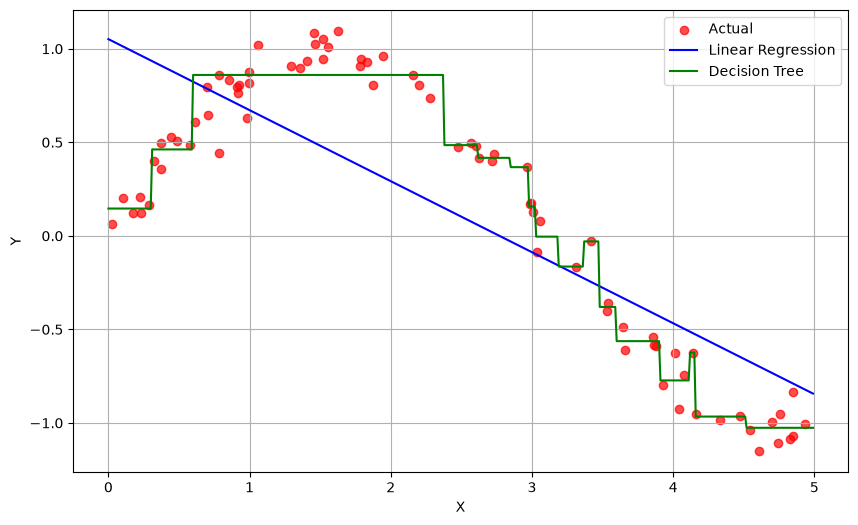

In [704]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='red', label='Actual', alpha=0.7)
plt.plot(X_test, y_pred_lr, color='blue', label='Linear Regression')
plt.plot(X_test, y_pred_dt, color='green', label='Decision Tree')
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()